# Neural Network from Scratch using NumPy

## Objective

In this notebook, we will build a small **feed-forward neural network with one hidden layer** using only NumPy.

We will implement everything manually:

- Forward propagation
- ReLU activation
- Sigmoid activation
- Binary cross-entropy loss
- Backward propagation
- Gradients
- Gradient descent
- Training loop
- Loss visualization

We will train the network on a toy **XOR dataset**.

### Why XOR?

A single perceptron cannot solve XOR because XOR is not linearly separable.

A neural network with a hidden layer can solve it.

```text
Input Layer       Hidden Layer       Output Layer

 x1 ───────────►   neuron 1 ───┐
                               │
 x2 ───────────►   neuron 2 ───┼──► output
                               │
               ...             │
```

The important idea is:

> **A hidden layer allows the network to learn non-linear relationships.**

## 1. Import Libraries

We only need:

- `numpy` → numerical calculations
- `matplotlib` → visualize the loss

We are intentionally not using TensorFlow or Keras.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Make random initialization reproducible
np.random.seed(42)

## 2. Create the XOR Dataset

Our input has two features:

- `x1`
- `x2`

The target is:

| x1 | x2 | XOR |
|---:|---:|----:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The network must learn this non-linear pattern.

In [3]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print("X:")
print(X)

print("\ny:")
print(y)

X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

y:
[[0.]
 [1.]
 [1.]
 [0.]]


## 3. Design the Neural Network

Our network will have:

```text
Input layer
    ↓
2 input neurons
    ↓
Hidden layer
    ↓
4 neurons
    ↓
Output layer
    ↓
1 neuron
```

So:

- Input size = `2`
- Hidden size = `4`
- Output size = `1`

The hidden layer will use **ReLU**.

The output layer will use **Sigmoid**, because this is binary classification.

### Network equations

First layer:

`Z1 = XW1 + b1`

`A1 = ReLU(Z1)`

Second layer:

`Z2 = A1W2 + b2`

`A2 = Sigmoid(Z2)`

`A2` is our final prediction.

## 4. Initialize Weights and Biases

The network needs parameters that it can learn.

We have:

- `W1` → weights from input layer to hidden layer
- `b1` → hidden-layer bias
- `W2` → weights from hidden layer to output layer
- `b2` → output-layer bias

The weights start with small random values.

The biases start at zero.

In [6]:
input_size = 2
hidden_size = 4
output_size = 1

# Input -> Hidden
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))

# Hidden -> Output
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)
print("W1:",W1)
print("b1:",b1)
print("W2:",W2)
print("b2:",b2)

W1 shape: (2, 4)
b1 shape: (1, 4)
W2 shape: (4, 1)
b2 shape: (1, 1)
W1: [[-0.27219136  0.05546129 -0.57549679  0.18784901]
 [-0.30031934 -0.14584687 -0.30085331  0.92613909]]
b1: [[0. 0. 0. 0.]]
W2: [[-0.00674861]
 [-0.52885546]
 [ 0.41127246]
 [-0.61042182]]
b2: [[0.]]


## 5. ReLU Activation

The hidden layer uses **ReLU**:

`ReLU(x) = max(0, x)`

Examples:

```text
ReLU(-3) = 0
ReLU( 0) = 0
ReLU( 5) = 5
```

ReLU introduces non-linearity into the network.

Without a non-linear activation, stacking multiple linear layers would still behave like a single linear transformation.

In [12]:
def relu(z):
    return np.maximum(0, z)


# Test ReLU
test_values = np.array([-3, -1, 0, 2, 5])

print("Input :", test_values)
print("ReLU  :", relu(test_values))

Input : [-3 -1  0  2  5]
ReLU  : [0 0 0 2 5]


## 6. Sigmoid Activation

The output layer uses Sigmoid.

Formula:

`sigmoid(z) = 1 / (1 + e^(-z))`

It converts any value into a number between `0` and `1`.

For example:

```text
large negative → close to 0
0              → 0.5
large positive → close to 1
```

This is useful for binary classification.

In [13]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


test_values = np.array([-5, -1, 0, 1, 5])

print("Input   :", test_values)
print("Sigmoid :", sigmoid(test_values))

Input   : [-5 -1  0  1  5]
Sigmoid : [0.00669285 0.26894142 0.5        0.73105858 0.99330715]


## 7. Forward Propagation

Forward propagation means sending the input through the network to produce a prediction.

### Step 1 — Input to hidden layer

`Z1 = XW1 + b1`

### Step 2 — Apply ReLU

`A1 = ReLU(Z1)`

### Step 3 — Hidden to output layer

`Z2 = A1W2 + b2`

### Step 4 — Apply Sigmoid

`A2 = Sigmoid(Z2)`

`A2` is our final prediction.

Notice that we save intermediate values such as `Z1`, `A1`, and `Z2`.

We will need them later during **backpropagation**.

In [14]:
def forward(X, W1, b1, W2, b2):
    # Input -> Hidden
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # Hidden -> Output
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # Cache values needed for backpropagation
    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache


predictions, cache = forward(X, W1, b1, W2, b2)

print("Initial predictions:")
print(predictions)

Initial predictions:
[[0.5       ]
 [0.36231383]
 [0.46406254]
 [0.33626071]]


## 8. Binary Cross-Entropy Loss

The network needs a way to measure how wrong its predictions are.

For binary classification we use **Binary Cross-Entropy**:

`Loss = -[y*log(prediction) + (1-y)*log(1-prediction)]`

We take the average over all training examples.

### Intuition

If the correct answer is `1`:

- prediction `0.99` → very small loss
- prediction `0.50` → larger loss
- prediction `0.01` → very large loss

The same idea applies when the correct answer is `0`.

The goal of training is:

> **Minimize the loss.**

In [15]:
def binary_cross_entropy(y_true, y_pred):
    # Prevent log(0), which would produce numerical problems
    epsilon = 1e-8

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

    return loss


loss = binary_cross_entropy(y, predictions)

print("Initial loss:", loss)

Initial loss: 0.7214983737597189


## 9. Backpropagation — The Important Part

Forward propagation calculates the prediction.

**Backpropagation calculates how each parameter contributed to the error.**

We calculate gradients starting from the output and move backward.

For this network:

```text
Loss
 ↓
Output layer
 ↓
Hidden layer
 ↓
Input layer
```

For sigmoid + binary cross-entropy, the output gradient simplifies to:

`dZ2 = A2 - y`

Then:

`dW2 = A1ᵀ · dZ2`

`db2 = sum(dZ2)`

Next we move into the hidden layer:

`dA1 = dZ2 · W2ᵀ`

Because the hidden layer uses ReLU:

`dZ1 = dA1 * ReLU'(Z1)`

Then:

`dW1 = Xᵀ · dZ1`

`db1 = sum(dZ1)`

These gradients tell us which direction each weight and bias should move.

In [16]:
def relu_derivative(z):
    # ReLU derivative:
    # 1 when z > 0
    # 0 when z <= 0
    return (z > 0).astype(float)


def backward(X, y, cache, W2):
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    m = X.shape[0]

    # -------------------------
    # Output layer gradients
    # -------------------------

    # For sigmoid + binary cross-entropy
    dZ2 = A2 - y

    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # -------------------------
    # Hidden layer gradients
    # -------------------------

    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

## 10. Gradient Descent

Now that we know the gradients, we update the parameters.

The basic rule is:

`parameter = parameter - learning_rate * gradient`

Why subtract?

Because the gradient points toward increasing loss.

We want to move in the opposite direction to reduce the loss.

For example:

`W1 = W1 - learning_rate * dW1`

The same happens for all weights and biases.

## 11. Train the Neural Network

We now combine everything into a training loop.

Each epoch performs:

```text
1. Forward propagation
2. Calculate loss
3. Backpropagation
4. Calculate gradients
5. Update weights and biases
```

We repeat this many times.

If learning is working, the loss should gradually decrease.

In [17]:
learning_rate = 0.5
epochs = 10000

loss_history = []

for epoch in range(epochs):

    # -------------------------
    # 1. Forward propagation
    # -------------------------
    predictions, cache = forward(
        X, W1, b1, W2, b2
    )

    # -------------------------
    # 2. Calculate loss
    # -------------------------
    loss = binary_cross_entropy(y, predictions)

    loss_history.append(loss)

    # -------------------------
    # 3. Backpropagation
    # -------------------------
    dW1, db1, dW2, db2 = backward(
        X, y, cache, W2
    )

    # -------------------------
    # 4. Update parameters
    # -------------------------
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # Print progress
    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss:.6f}")

Epoch     0 | Loss: 0.721498
Epoch  1000 | Loss: 0.477611
Epoch  2000 | Loss: 0.477619
Epoch  3000 | Loss: 0.477453
Epoch  4000 | Loss: 0.477423
Epoch  5000 | Loss: 0.477424
Epoch  6000 | Loss: 0.477425
Epoch  7000 | Loss: 0.477404
Epoch  8000 | Loss: 0.477426
Epoch  9000 | Loss: 0.477404


## 12. Visualize the Loss

Let's plot the loss during training.

If the network is learning correctly, the curve should generally move downward.

This gives us a visual confirmation that gradient descent is improving the model.

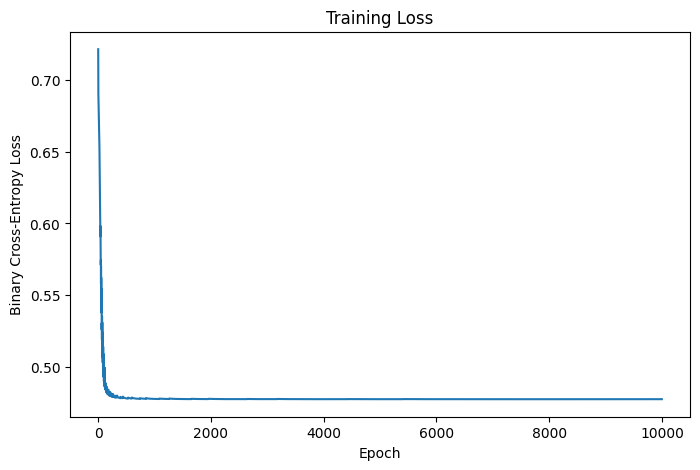

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss")

plt.show()

## 13. Test the Trained Network

Now we run the trained network on the XOR examples.

The output of the sigmoid is a probability.

For example:

```text
0.02 → likely class 0
0.95 → likely class 1
```

We convert probabilities into binary predictions using a threshold of `0.5`.

- `prediction >= 0.5` → class `1`
- `prediction < 0.5` → class `0`

In [19]:
final_probabilities, _ = forward(
    X, W1, b1, W2, b2
)

final_predictions = (final_probabilities >= 0.5).astype(int)

print("Input | Expected | Probability | Prediction")
print("-" * 50)

for inputs, target, probability, prediction in zip(
    X,
    y,
    final_probabilities,
    final_predictions
):
    print(
        f"{inputs}    |    {int(target[0])}     |"
        f"    {probability[0]:.4f}    |"
        f"     {prediction[0]}"
    )

Input | Expected | Probability | Prediction
--------------------------------------------------
[0. 0.]    |    0     |    0.6666    |     1
[0. 1.]    |    1     |    0.6666    |     1
[1. 0.]    |    1     |    0.6666    |     1
[1. 1.]    |    0     |    0.0002    |     0


## 14. Calculate Accuracy

Let's check how many XOR examples the network classified correctly.

In [20]:
accuracy = np.mean(final_predictions == y)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 75.00%


## 15. Understand What the Network Learned

The network has learned XOR using the hidden layer.

Conceptually:

```text
                Hidden neurons
               ┌───────────────┐
x1 ────────────►│               │
                │   Non-linear  │────► Output
x2 ────────────►│ transformations│
                │               │
                └───────────────┘
```

The hidden neurons learn intermediate representations of the input.

This is the key difference from the single perceptron.

### Single perceptron

```text
X → Linear calculation → Output
```

### Neural network

```text
X → Linear calculation
  → Non-linear activation
  → Linear calculation
  → Non-linear activation
  → Output
```

The hidden layer gives the model the ability to learn non-linear patterns.

# 16. Full Learning Flow

The complete training process is:

```text
                 FORWARD PROPAGATION

X
│
▼
Z1 = XW1 + b1
│
▼
A1 = ReLU(Z1)
│
▼
Z2 = A1W2 + b2
│
▼
A2 = Sigmoid(Z2)
│
▼
Prediction
│
▼
Loss
│
│
▼
              BACKWARD PROPAGATION

dZ2 = A2 - y
│
▼
dW2, db2
│
▼
dA1
│
▼
dZ1
│
▼
dW1, db1
│
▼
Update W1, b1, W2, b2
│
└──────────────► Repeat
```

### The big picture

**Forward propagation** answers:

> What does the network predict?

**Loss function** answers:

> How wrong is the prediction?

**Backpropagation** answers:

> How should each parameter change?

**Gradient descent** performs:

> Actually change the parameters to reduce the loss.

# 17. Key Concepts Learned

| Concept | What it does |
|---|---|
| Weight | Controls the strength of an input |
| Bias | Shifts the activation |
| Forward propagation | Calculates predictions |
| ReLU | Adds non-linearity in hidden layer |
| Sigmoid | Converts output to probability |
| Loss | Measures prediction error |
| Backpropagation | Calculates gradients |
| Gradient | Direction/rate of parameter change |
| Gradient descent | Updates parameters to reduce loss |
| Epoch | One complete pass through training data |
| Hidden layer | Learns intermediate representations |

## Most important formulas

### Forward propagation

`Z1 = XW1 + b1`

`A1 = ReLU(Z1)`

`Z2 = A1W2 + b2`

`A2 = Sigmoid(Z2)`

### Loss

`Binary Cross-Entropy`

### Backpropagation

`dZ2 = A2 - y`

`dW2 = A1ᵀ · dZ2`

`dZ1 = dA1 * ReLU'(Z1)`

`dW1 = Xᵀ · dZ1`

### Gradient descent

`W = W - learning_rate * gradient`

---

## Connection to TensorFlow/Keras

Everything we manually implemented here is something TensorFlow/Keras normally automates.

```text
Our NumPy code
     ↓
Forward propagation
     ↓
Loss
     ↓
Backpropagation
     ↓
Gradients
     ↓
Parameter updates
```

With Keras, you would define the same architecture using layers, loss, and an optimizer, and the framework handles the forward/backward calculations.

Understanding this NumPy implementation first makes **TensorFlow/Keras much easier to understand**, because you know what is happening underneath the APIs.

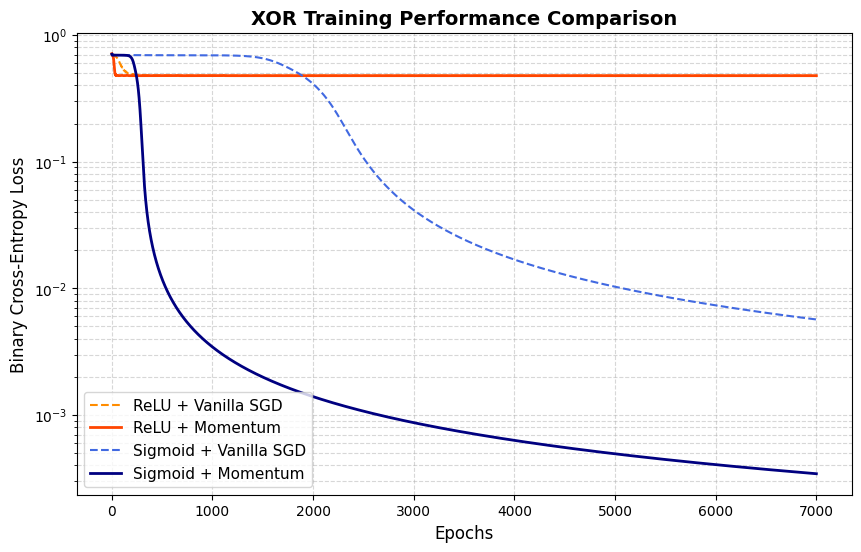

[np.float64(0.7214983737597189), np.float64(0.7034284777345348), np.float64(0.6951383875690866), np.float64(0.690055505095525), np.float64(0.6882381032838653), np.float64(0.6866733042616423), np.float64(0.6847145391862905), np.float64(0.6829665004055889), np.float64(0.6821693357904738), np.float64(0.6802527509638017), np.float64(0.6785604225435142), np.float64(0.677623709491701), np.float64(0.6754699187672728), np.float64(0.6738756622416782), np.float64(0.6723897391762197), np.float64(0.6698353428793655), np.float64(0.6683602308907131), np.float64(0.6660738358466884), np.float64(0.6629774107252785), np.float64(0.6616125664299638), np.float64(0.658337446638458), np.float64(0.6548819897557674), np.float64(0.6529588832810654), np.float64(0.6486208803690561), np.float64(0.6453213389164147), np.float64(0.6420882634537537), np.float64(0.6368277559161181), np.float64(0.6336234910362702), np.float64(0.6295008196109777), np.float64(0.6297987446856075), np.float64(0.6224205455185757), np.float64

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset Setup
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

# 2. Activation Functions & Derivatives
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    # Note: Expects 'a' to be the post-sigmoid activation value
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 3. Flexible Training Engine
def train_network(activation_type='relu', use_momentum=False, epochs=5000, lr=0.1, beta=0.9):
    np.random.seed(42) # Ensure fair initial weights across all tests

    # Initialization
    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.5
    b2 = np.zeros((1, 1))

    # Momentum velocity buffers
    v_W1, v_b1 = np.zeros_like(W1), np.zeros_like(b1)
    v_W2, v_b2 = np.zeros_like(W2), np.zeros_like(b2)

    loss_history = []
    m = X.shape[0]

    for epoch in range(epochs):
        # --- FORWARD PASS ---
        Z1 = np.dot(X, W1) + b1
        if activation_type == 'relu':
            A1 = relu(Z1)
        else:
            A1 = sigmoid(Z1)

        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2) # Output layer always uses Sigmoid for binary tasks

        # Track Loss
        loss_history.append(binary_cross_entropy(y, A2))

        # --- BACKPROPAGATION ---
        dZ2 = A2 - y
        dW2 = np.dot(A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, W2.T)
        if activation_type == 'relu':
            dZ1 = dA1 * relu_derivative(Z1)
        else:
            dZ1 = dA1 * sigmoid_derivative(A1)

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # --- OPTIMIZATION STEP ---
        if use_momentum:
            # Update velocities
            v_W1 = beta * v_W1 + lr * dW1
            v_b1 = beta * v_b1 + lr * db1
            v_W2 = beta * v_W2 + lr * dW2
            v_b2 = beta * v_b2 + lr * db2

            # Apply updates
            W1 -= v_W1
            b1 -= v_b1
            W2 -= v_W2
            b2 -= v_b2
        else:
            # Vanilla SGD
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2

    return loss_history

# 4. Run Configurations
epochs = 7000
lr = 0.3

history_relu_sgd = train_network('relu', use_momentum=False, epochs=epochs, lr=lr)
history_relu_mom = train_network('relu', use_momentum=True, epochs=epochs, lr=lr)
history_sig_sgd  = train_network('sigmoid', use_momentum=False, epochs=epochs, lr=lr)
history_sig_mom  = train_network('sigmoid', use_momentum=True, epochs=epochs, lr=lr)

# 5. Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(history_relu_sgd, label='ReLU + Vanilla SGD', color='darkorange', linestyle='--')
plt.plot(history_relu_mom, label='ReLU + Momentum', color='orangered', linewidth=2)
plt.plot(history_sig_sgd,  label='Sigmoid + Vanilla SGD', color='royalblue', linestyle='--')
plt.plot(history_sig_mom,  label='Sigmoid + Momentum', color='navy', linewidth=2)

plt.title("XOR Training Performance Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
plt.yscale('log') # Log scale helps emphasize differences near zero loss
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

print(loss_history)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

Final Trained Predictions (Keras):
Input: [0 0] -> Target: 0 -> Model Output: 0.0123 (Class 0)
Input: [0 1] -> Target: 1 -> Model Output: 0.9977 (Class 1)
Input: [1 0] -> Target: 1 -> Model Output: 0.9977 (Class 1)
Input: [1 1] -> Target: 0 -> Model Output: 0.0015 (Class 0)


/tmp/ipykernel_4285/1582066548.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Input: {X[i].astype(int)} -> Target: {int(y[i])} -> Model Output: {predictions[i][0]:.4f} (Class {binary_pred})")


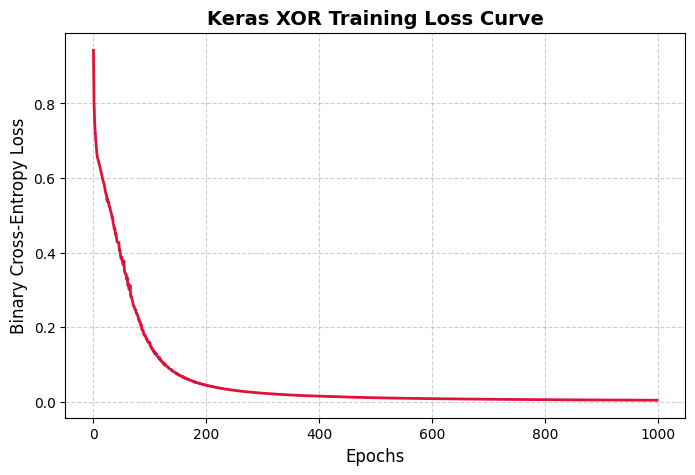

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# 1. Create the XOR Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

# 2. Build the Model (Exactly matching your architecture)
model = Sequential([
    # Hidden Layer: 4 neurons, ReLU activation, accepts 2 input features
    Dense(units=4, activation='relu', input_shape=(2,)),

    # Output Layer: 1 neuron, Sigmoid activation for binary classification
    Dense(units=1, activation='sigmoid')
])

# 3. Compile the Model (Setting up Optimizer and Loss Function)
# Using Vanilla SGD with your learning rate of 0.5
model.compile(
    optimizer=SGD(learning_rate=0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Train the Network
# Running for fewer epochs (1000) because Keras optimized execution is highly efficient
history = model.fit(
    X, y,
    epochs=1000,
    verbose=0 # Turn off step-by-step logs; we will print the final output
)

# 5. Verify Predictions
predictions = model.predict(X)
print("\nFinal Trained Predictions (Keras):")
for i in range(4):
    binary_pred = 1 if predictions[i] >= 0.5 else 0
    print(f"Input: {X[i].astype(int)} -> Target: {int(y[i])} -> Model Output: {predictions[i][0]:.4f} (Class {binary_pred})")

# 6. Plot the Keras Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], color='crimson', linewidth=2)
plt.title("Keras XOR Training Loss Curve", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
